In [1]:
import pandas as pd

In [15]:
df = pd.read_csv('encodingdata.csv')

In [16]:
# one-Hot-Encoding
encoded = pd.get_dummies(df,columns=['City'])
print(encoded)


   Temperature  City_Chennai  City_Delhi  City_Mumbai
0           34          True       False        False
1           30         False        True        False
2           32         False       False         True
3           29         False        True        False
4           35          True       False        False
5           33         False       False         True


In [17]:
encoded = pd.get_dummies(df,columns=['City']).astype(int)
print(encoded)

   Temperature  City_Chennai  City_Delhi  City_Mumbai
0           34             1           0            0
1           30             0           1            0
2           32             0           0            1
3           29             0           1            0
4           35             1           0            0
5           33             0           0            1


In [18]:
# remove one column to avoid dummy variable Trap

pd.get_dummies(df['City'],drop_first=True)

,Delhi,Mumbai
0,False,False
1,True,False
2,False,True
3,True,False
4,False,False
5,False,True


In [19]:
encoded.head()

,Temperature,City_Chennai,City_Delhi,City_Mumbai
0,34,1,0,0
1,30,0,1,0
2,32,0,0,1
3,29,0,1,0
4,35,1,0,0


In [20]:
df.head()

,City,Temperature
0,Chennai,34
1,Delhi,30
2,Mumbai,32
3,Delhi,29
4,Chennai,35


In [24]:
#frequency Encoding

frequency = df['City'].value_counts()
df['City_freq'] = df['City'].map(frequency)


In [27]:
df.head(10)

,City,Temperature,City_freq
0,Chennai,34,2
1,Delhi,30,2
2,Mumbai,32,2
3,Delhi,29,2
4,Chennai,35,2
5,Mumbai,33,2


In [29]:
#target Encoding 

target_mean = df.groupby("City")["Temperature"].mean()

df["City_encoded"] = df["City"].map(target_mean)

In [30]:
df.head(10)

,City,Temperature,City_freq,City_encoded
0,Chennai,34,2,34.5
1,Delhi,30,2,29.5
2,Mumbai,32,2,32.5
3,Delhi,29,2,29.5
4,Chennai,35,2,34.5
5,Mumbai,33,2,32.5


                                                            netflix dataset         

In [33]:
df = pd.read_csv('netflixcleaned.csv',index_col=0)

In [34]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons


In [35]:
#one-hot-encoding

encoded = pd.get_dummies(df, columns=['type'], dtype=int)
encoded


,show_id,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_unit,type_Movie,type_TV Show
0,s1,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min,1,0
1,s2,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons,0,1
2,s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season,0,1
3,s4,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season,0,1
4,s5,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158,min,1,0
8803,s8804,Zombie Dumb,unknown,unknown,unknown,2019-07-01,2018,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2,Seasons,0,1
8804,s8805,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88,min,1,0
8805,s8806,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88,min,1,0


In [36]:
# remove one column to avoid dummy variable Trap

pd.get_dummies(df['type'],drop_first=True)

,TV Show
0,False
1,True
2,True
3,True
4,True
...,...
8802,False
8803,True
8804,False
8805,False


In [39]:
#frequency Encoding

frequency = df['rating'].value_counts()
df['rating_freq'] = df['rating'].map(frequency)

In [40]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_unit,rating_freq
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min,490
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons,3209
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season,3209
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season,3209
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons,3209
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",unknown,2021-09-24,2021,TV-MA,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1,Season,3209
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,2021-09-24,2021,PG,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91,min,287
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125,min,3209
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9,Seasons,2157
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104,min,490


In [ ]:
#frequency Encoding

frequency = df['country'].value_counts()Í
df['country_freq'] = df['country'].map(frequency)

In [42]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_unit,rating_freq,country_freq
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min,490,2812
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons,3209,30
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season,3209,830
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season,3209,830
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons,3209,972
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",unknown,2021-09-24,2021,TV-MA,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1,Season,3209,830
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",unknown,2021-09-24,2021,PG,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91,min,287,830
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125,min,3209,1
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,9,Seasons,2157,418
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104,min,490,2812


for target encoding

In [31]:
import pandas as pd
from category_encoders import TargetEncoder
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [25]:
data = {
    "product_category": ["electronics","clothing","electronics","books","clothing","electronics","books"],
    "price":[500,40,600,15,35,450,20],
    "purchased":[1,0,1,0,1,1,0]
}

In [26]:
df = pd.DataFrame(data)

In [27]:
df.head()

,product_category,price,purchased
0,electronics,500,1
1,clothing,40,0
2,electronics,600,1
3,books,15,0
4,clothing,35,1


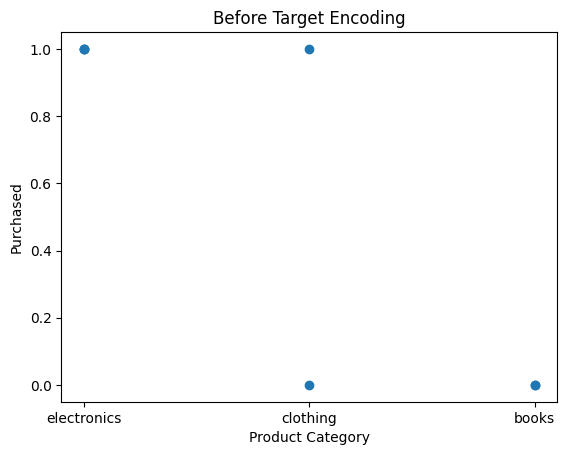

In [28]:
plt.scatter(df["product_category"], df["purchased"])
plt.xlabel("Product Category")
plt.ylabel("Purchased")
plt.title("Before Target Encoding")
plt.show()

In [29]:
target_mean = df.groupby("product_category")["purchased"].mean()
df["category_encoded"] = df["product_category"].map(target_mean)

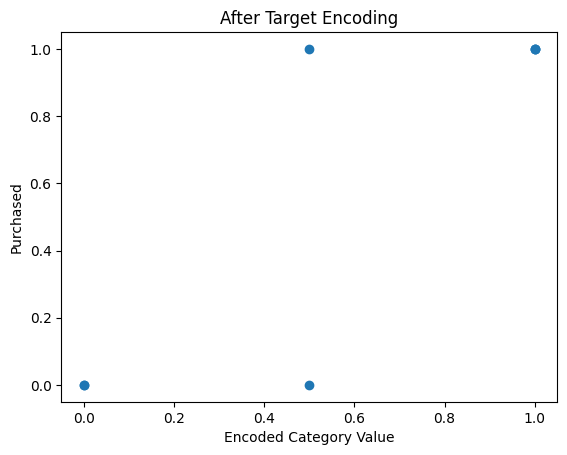

In [30]:

plt.scatter(df["category_encoded"], df["purchased"])
plt.xlabel("Encoded Category Value")
plt.ylabel("Purchased")
plt.title("After Target Encoding")
plt.show()

,product_category,price
0,0.637628,500
1,0.561296,40
2,0.637628,600
3,0.490371,15
4,0.561296,35
5,0.637628,450
6,0.490371,20


In [ ]:
# Linear Regression

X = df[["category_encoded"]]
y = df["purchased"]

model = LinearRegression()
model.fit(X,y)

y_pred = model.predict(X)

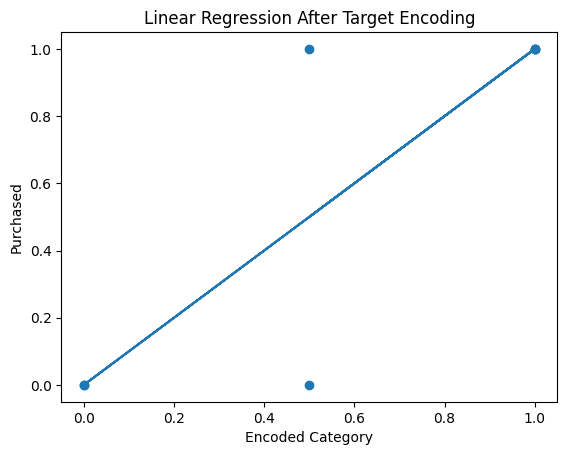

In [33]:
plt.scatter(df["category_encoded"], y)
plt.plot(df["category_encoded"], y_pred)
plt.xlabel("Encoded Category")
plt.ylabel("Purchased")
plt.title("Linear Regression After Target Encoding")
plt.show()

In [58]:
new_data = pd.DataFrame({
    "product_category": ["electronics","books","clothing"],
    "price":[550,25,50]
})

In [59]:
new_data.head()

,product_category,price
0,electronics,550
1,books,25
2,clothing,50
